In [102]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [103]:
df=pd.read_csv(r"S:\csv folder\marketing_campaign.csv",sep="\t")

In [104]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [105]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [106]:
df.dropna(inplace=True)

In [107]:
df.duplicated().sum()

np.int64(0)

2. Visualize spending patterns and demographics.


In [108]:
spending_cols = ['MntWines','MntFruits','MntMeatProducts',
                 'MntFishProducts','MntSweetProducts','MntGoldProds']

df['Total_Spending'] = df[spending_cols].sum(axis=1)

df['Total_Spending']

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spending, Length: 2216, dtype: int64

3. Normalize numerical features (spending, income).

In [109]:
cols = ['Income'] + spending_cols
scaler = StandardScaler()
df_cols = scaler.fit_transform(df[cols])
df_cols

array([[ 0.2340627 ,  0.97822575,  1.54942946, ...,  2.45456767,
         1.48482696,  0.85003057],
       [-0.23455948, -0.87202383, -0.63732782, ..., -0.65103787,
        -0.63388018, -0.73286728],
       [ 0.76947764,  0.35851074,  0.56915896, ...,  1.34020333,
        -0.14682107, -0.03793652],
       ...,
       [ 0.18809052,  1.78770994,  0.54402382, ..., -0.10298983,
        -0.36599767, -0.3854019 ],
       [ 0.67538765,  0.36444103,  0.09159127, ...,  0.77388702,
         0.07235553,  0.3288325 ],
       [ 0.02470453, -0.65556835, -0.58705754, ..., -0.65103787,
        -0.63388018, -0.44331279]], shape=(2216, 7))

In [110]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Total_Spending'],
      dtype='object')

4. Choose optimal number of clusters using Elbow
method.


In [138]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [112]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_cols)  # use normalized features
    wcss.append(kmeans.inertia_)
    

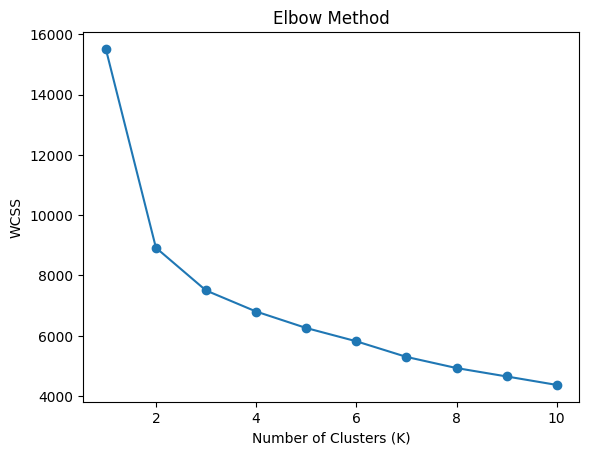

In [113]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2216 non-null   int64  
 1   Year_Birth           2216 non-null   int64  
 2   Education            2216 non-null   object 
 3   Marital_Status       2216 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2216 non-null   int64  
 6   Teenhome             2216 non-null   int64  
 7   Dt_Customer          2216 non-null   object 
 8   Recency              2216 non-null   int64  
 9   MntWines             2216 non-null   int64  
 10  MntFruits            2216 non-null   int64  
 11  MntMeatProducts      2216 non-null   int64  
 12  MntFishProducts      2216 non-null   int64  
 13  MntSweetProducts     2216 non-null   int64  
 14  MntGoldProds         2216 non-null   int64  
 15  NumDealsPurchases    2216 non-null   int64 

5. Apply K-Means clustering.

In [128]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit model and predict clusters
df['Cluster'] = kmeans.fit_predict(df_cols)


In [116]:
centers = kmeans.cluster_centers_
print(centers)

[[ 0.5574043   0.88273145 -0.00426682  0.29064802  0.02443856  0.01076695
   0.52247948]
 [-0.59940997 -0.67072461 -0.51622588 -0.60444041 -0.53160532 -0.51401174
  -0.51364447]
 [ 0.96982933  0.74006986  1.48061686  1.33966881  1.48630669  1.45425744
   0.77132419]]


6. Apply Hierarchical clustering and compare.


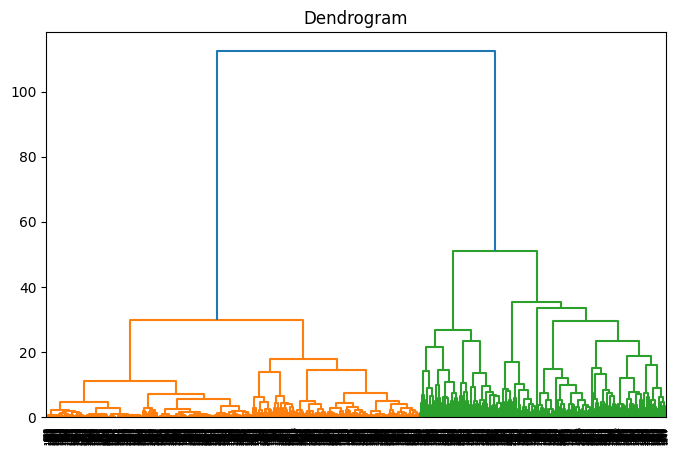

In [117]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Dendrogram
linked = linkage(df_cols, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

# Agglomerative clustering


In [118]:
hc = AgglomerativeClustering(n_clusters=5)
df['HC_Cluster'] = hc.fit_predict(df_cols)

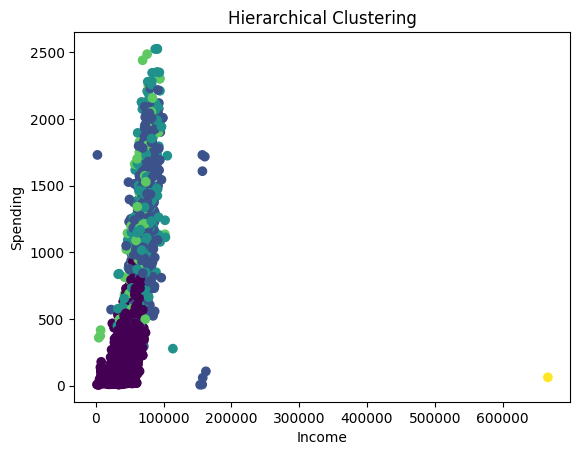

In [119]:
plt.scatter(df['Income'], df['Total_Spending'], c=df['HC_Cluster'])

plt.xlabel('Income')
plt.ylabel('Spending')
plt.title('Hierarchical Clustering')
plt.show()

7.Visualize clusters using PCA or t-SNE.

In [135]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_cols)

df['PCA1'] = pca_components[:,0]
df['PCA2'] = pca_components[:,1]



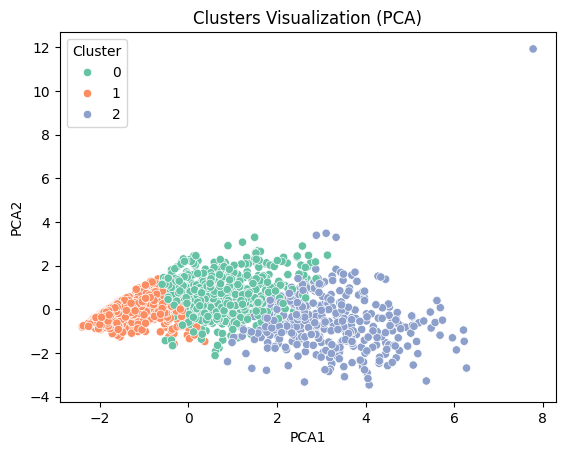

In [142]:
sns.scatterplot(data=df,x='PCA1', y='PCA2', hue='Cluster',  palette='Set2')
plt.title("Clusters Visualization (PCA)")
plt.show()

8.Profile each cluster (age).

In [143]:
df['Age'] = 2026 - df['Year_Birth']

In [144]:
df['Age']

0       69
1       72
2       61
3       42
4       45
        ..
2235    59
2236    80
2237    45
2238    70
2239    72
Name: Age, Length: 2216, dtype: int64

9.Label original dataset with cluster IDs.

In [145]:
df['Cluster_ID'] = df['Cluster']

In [146]:
df['Cluster_ID']


0       2
1       1
2       0
3       1
4       1
       ..
2235    2
2236    1
2237    0
2238    0
2239    1
Name: Cluster_ID, Length: 2216, dtype: int32

In [149]:
df['Cluster_ID_hc'] = df['HC_Cluster']
df['Cluster_ID_hc']

0       2
1       0
2       1
3       0
4       0
       ..
2235    3
2236    0
2237    1
2238    1
2239    0
Name: Cluster_ID_hc, Length: 2216, dtype: int64